# AI in Digital Pathology - Video 3
## Tissue Classification Across the Breast Disease Spectrum
### Phikon-v2 + Logistic Regression on BR2082c TMA Cores

**What this notebook covers:**

In Video 2 we extracted patch embeddings and showed that tumor and normal tissue separate in embedding space. This video takes the next step: we use those same embeddings to classify real tissue cores across a full breast disease spectrum.

**Dataset:** BR2082c tissue microarray - 187 breast tissue cores spanning metastatic carcinoma, invasive carcinoma, ductal carcinoma in situ (DCIS), and normal/benign tissue. Each core is a 3000x3000 px H&E image with a pathologist-assigned diagnosis.

**The workflow:**
1. Load core labels from the TMA spec sheet (Excel)
2. Tile each core into 256x256 patches, skip near-white background tiles
3. Extract Phikon-v2 embeddings for every non-background tile
4. Aggregate tile embeddings per core using mean pooling
5. Train a logistic regression on core embeddings
6. Evaluate on held-out test cores
7. Visualize: UMAP of core embeddings, confusion matrix, tile-level heatmaps

**Key teaching point:** We have core-level labels only - no tile annotations. Mean pooling patch embeddings into a single core-level vector is the simplest form of weakly supervised learning. In Video 4 (ABMIL) we replace mean pooling with attention pooling and the model learns which tiles matter most.

**Environment:** `torch-gpu-pathology` conda environment.

## Cell 1: Imports and environment check

In [1]:
import os
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
VRAM: 21.5 GB


## Cell 2: Paths

Adjust `PROJECT_ROOT` if needed. The Excel spec sheet and core images live under `images/P1522Q0001-0008/`.

In [2]:
PROJECT_ROOT = r"C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology"

TMA_DIR     = os.path.join(PROJECT_ROOT, "images", "P1522Q0001-0008")
CORE_DIR    = os.path.join(TMA_DIR, "core_images")
EXCEL_PATH  = os.path.join(TMA_DIR, "BR2082c specs.xlsx")
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, "results", "video3")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Where we cache extracted embeddings so we never rerun Phikon-v2
EMBED_CACHE = os.path.join(OUTPUT_DIR, "core_embeddings.npz")

print(f"Core images: {CORE_DIR}")
print(f"Excel:       {EXCEL_PATH}")
print(f"Outputs:     {OUTPUT_DIR}")
print(f"Excel exists: {os.path.exists(EXCEL_PATH)}")
print(f"Core dir exists: {os.path.exists(CORE_DIR)}")

Core images: C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\images\P1522Q0001-0008\core_images
Excel:       C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\images\P1522Q0001-0008\BR2082c specs.xlsx
Outputs:     C:\Users\m6sbhatt\Documents\Personal\python_projects\AI_in_Digital_Pathology\results\video3
Excel exists: True
Core dir exists: True


## Cell 3: Load and parse the TMA spec sheet

The Excel file has one row per core. The position column (A1, B3, etc.) maps directly to the image filename suffix. We load all 192 rows, then filter to the four classes we use in this video:

- **Metastatic** - metastatic carcinoma from breast (rows A-B, lymph node origin)
- **Invasive** - invasive carcinoma of no special type (rows C-G)
- **DCIS** - ductal carcinoma in situ (rows H-I)
- **Normal/Benign** - fibroadenoma, hyperplasia, adjacent normal, cancer-adjacent tissue (rows J-L)

We skip the smaller categories (lobular carcinoma, squamous cell carcinoma, inflammation) to keep the class sizes balanced and the lesson focused. Those categories have 5-21 cores each - not enough for a robust split.

We also check which image files actually exist on disk. We have 187 of the 192 listed cores - the 5 missing ones are simply excluded.

In [3]:
# The filename prefix is constant across all cores
FNAME_PREFIX = "P1522Q0001-0008-1522-H&E-(06.07.19)_"

# Load Excel - skip the header rows, start from the Position column
df_raw = pd.read_excel(EXCEL_PATH, skiprows=5, header=0)

# The spec sheet columns: Position, No., Age, Sex, Organ, Pathology diagnosis,
# TNM, Grade, Stage, Type, Tissue ID, ER, PR, HER2, Ki67
df_raw.columns = [
    'Position', 'No', 'Age', 'Sex', 'Organ', 'Diagnosis',
    'TNM', 'Grade', 'Stage', 'Type', 'TissueID',
    'ER', 'PR', 'HER2', 'Ki67'
]

# Drop rows without a valid position (empty rows at end of sheet)
df_raw = df_raw.dropna(subset=['Position'])
df_raw['Position'] = df_raw['Position'].astype(str).str.strip()

print(f"Total rows in spec sheet: {len(df_raw)}")
print(f"Unique diagnosis types:")
for d in sorted(df_raw['Diagnosis'].dropna().unique()):
    print(f"  {d}")

Total rows in spec sheet: 196
Unique diagnosis types:
  Acute mastitis
  Adenosis
  Adjacent normal breast tissue
  Adjacent normal breast tissue (adenosis) of No.9
  Adjacent normal breast tissue (sparse)
  Adjacent normal breast tissue of No.117
  Breast tissue
  Cancer adjacent breast tissue
  Cancer adjacent breast tissue (chronic mastitis)
  Cancer adjacent breast tissue (fibrous tissue)
  Cancer adjacent breast tissue of No.140
  Cancer adjacent breast tissue(fibrous tissue)
  Chronic mastitis
  Chronic mastitis No.135
  Chronic mastitis of No.66
  Ductal carcinoma in situ
  Ductal carcinoma in situ (sparse)
  Ductal carcinoma in situ with invasion
  Ductal carcinoma in situ(breast tissue)
  Ductal carcinoma in situ（fibrous tissue）
  Ductal papillomatosis with hyperplasia
  Fibroadenoma
  Hyperplasia
  Intraductal papillary carcinoma
  Invasive carcinoma of no special type
  Invasive carcinoma of no special type (sparse)
  Invasive lobular carcinoma
  Metastatic carcinoma from br

## Cell 4: Assign class labels and build the core dataframe

We map each diagnosis string to one of four class labels. The mapping uses substring matching so it handles minor variations in wording.

In [4]:
def assign_class(diagnosis):
    if not isinstance(diagnosis, str):
        return None
    d = diagnosis.lower()
    if 'metastatic' in d or 'invasive carcinoma of no special type' in d:
        return 0  # Carcinoma (invasive + metastatic merged)
    if 'ductal carcinoma in situ' in d or 'intraductal' in d:
        return 1  # DCIS
    if any(x in d for x in ['fibroadenoma', 'hyperplasia', 'adjacent normal',
                              'cancer adjacent', 'breast tissue', 'adenosis',
                              'mastitis', 'papillomatosis']):
        return 2  # Normal/Benign
    return None

CLASS_NAMES  = ['Carcinoma', 'DCIS', 'Normal/Benign']
CLASS_COLORS = ['#DC2626', '#0D9488', '#1B2A4A']
CLASS_SHORT  = ['CAR', 'DCIS', 'NB']

df_raw['ClassID'] = df_raw['Diagnosis'].apply(assign_class)

# Keep only the four classes
df = df_raw[df_raw['ClassID'].notna()].copy()
df['ClassID'] = df['ClassID'].astype(int)

# Build image path for each core
df['ImagePath'] = df['Position'].apply(
    lambda pos: os.path.join(CORE_DIR, f"{FNAME_PREFIX}{pos}.png")
)

# Check which files actually exist
df['FileExists'] = df['ImagePath'].apply(os.path.exists)
df = df[df['FileExists']].copy()

print(f"Cores after class filtering and file check: {len(df)}")
print()
print("Class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    n = (df['ClassID'] == cls_id).sum()
    print(f"  {cls_id} {cls_name}: {n} cores")

Cores after class filtering and file check: 162

Class distribution:
  0 Carcinoma: 97 cores
  1 DCIS: 18 cores
  2 Normal/Benign: 47 cores


## Cell 5: Visualize sample cores from each class

Before running any model, always look at the data. We display three representative cores per class. This confirms the label mapping is correct and gives the audience visual context for what each class looks like.

The cores are 3000x3000 - we display them downsampled for speed.

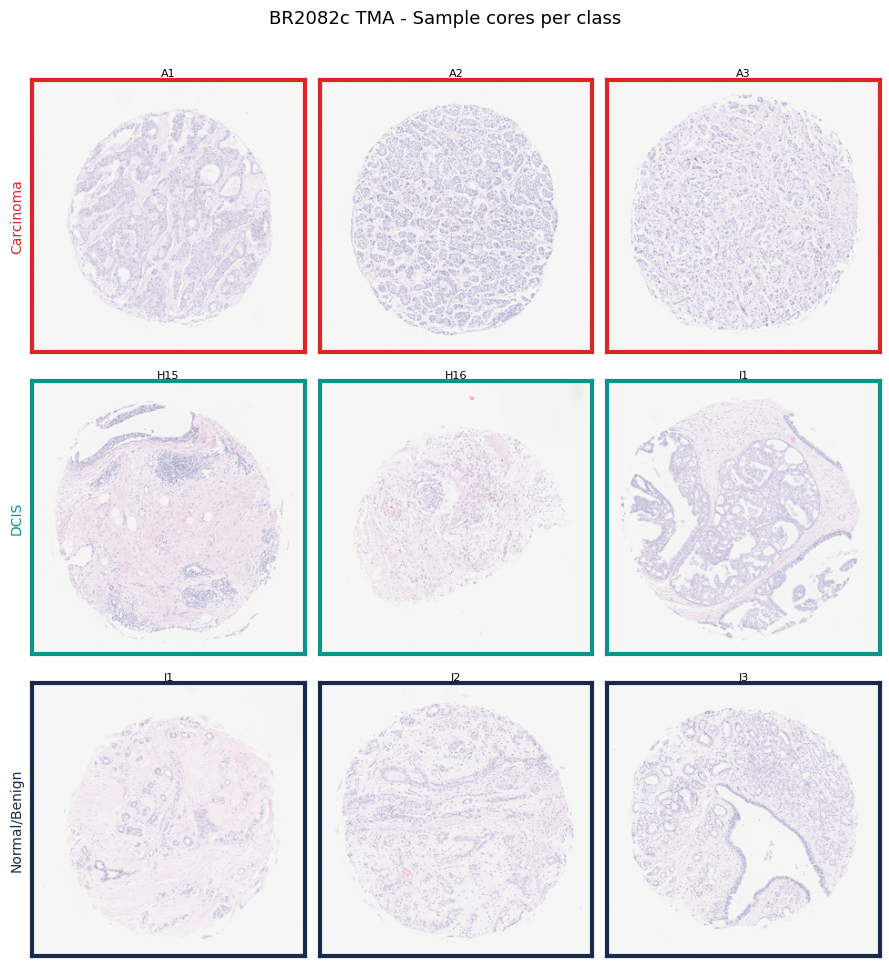

Saved: sample_cores.png


In [5]:
N_SHOW = 3
fig, axes = plt.subplots(len(CLASS_NAMES), N_SHOW,
                          figsize=(N_SHOW * 3.0, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor('white')

for cls_id, (cls_name, cls_color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    cls_rows = df[df['ClassID'] == cls_id].head(N_SHOW)

    for k, (_, row) in enumerate(cls_rows.iterrows()):
        ax = axes[cls_id, k]
        # Downsample to 300x300 for display speed
        img = Image.open(row['ImagePath']).convert('RGB').resize((300, 300))
        ax.imshow(np.array(img))
        ax.set_title(f"{row['Position']}", fontsize=8,
                     fontname='DejaVu Sans', pad=2)
        for spine in ax.spines.values():
            spine.set_edgecolor(cls_color)
            spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel(cls_name, fontsize=10, fontname='DejaVu Sans',
                          color=cls_color, rotation=90, labelpad=6)

plt.suptitle('BR2082c TMA - Sample cores per class',
             fontname='DejaVu Sans', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_cores.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: sample_cores.png")

## Cell 6: Load Phikon-v2

Same as Video 2. Loads from local cache.

In [6]:
MODEL_NAME = "owkin/phikon-v2"

print("Loading Phikon-v2 ...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model     = model.to(device)
model.eval()
print(f"Model loaded on: {device}")

Loading Phikon-v2 ...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Model loaded on: cuda


## Cell 7: Define tiling and embedding functions

Two functions we reuse for every core:

`tile_core()` - divides a 3000x3000 image into non-overlapping 256x256 tiles, returns only tiles where the mean pixel value is below 230. That threshold filters out near-white background tiles - the empty space outside the circular TMA punch. A tile with mean > 230 is mostly white and carries no tissue information.

`embed_tiles()` - runs the retained tiles through Phikon-v2 in batches, returns a (N_tiles, 1024) array.

`core_embedding()` - calls both functions and returns the mean across all tile embeddings - a single 1024-dim vector representing the whole core. If no tiles survive the background filter (an empty core), returns None.

In [7]:
TILE_SIZE  = 256
STRIDE     = 256
BG_MEAN    = 243    # background mean ~245.7, tissue mean 228-240
BG_STD     = 4      # background std ~0.4, tissue std 4-15+
BATCH_SIZE = 32


def tile_core(img_np):
    """Tile a core image, return non-background tiles and their (row, col) coords.
    
    Background tiles have mean ~245.7 and std ~0.4.
    Tissue tiles (including partial) have mean 228-240 and std 4-15+.
    A tile is kept if it passes either threshold - partial tissue with
    std >= 4 is included even if mean is elevated.
    """
    H, W = img_np.shape[:2]
    tiles, coords = [], []
    for r in range(0, H - TILE_SIZE + 1, STRIDE):
        for c in range(0, W - TILE_SIZE + 1, STRIDE):
            tile = img_np[r:r + TILE_SIZE, c:c + TILE_SIZE]
            if tile.mean() <= BG_MEAN or tile.std() >= BG_STD:
                tiles.append(tile)
                coords.append((r, c))
    if not tiles:
        return np.array([]).reshape(0, TILE_SIZE, TILE_SIZE, 3), coords
    return np.array(tiles), coords


def embed_tiles(tiles):
    """Extract Phikon-v2 CLS embeddings for a batch of tiles. Returns (N, 1024)."""
    all_emb = []
    n_batches = int(np.ceil(len(tiles) / BATCH_SIZE))
    for i in range(n_batches):
        batch = tiles[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]
        pil_batch = [Image.fromarray(t) for t in batch]
        inputs = processor(images=pil_batch, return_tensors="pt").to(device)
        with torch.no_grad():
            out = model(**inputs)
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_emb)   # (N_tiles, 1024)


def core_embedding(img_path):
    """Load a core, tile it, embed non-background tiles, return mean embedding."""
    img_np = np.array(Image.open(img_path).convert('RGB'))
    tiles, coords = tile_core(img_np)
    if len(tiles) == 0:
        return None, 0, []
    embs = embed_tiles(tiles)
    return embs.mean(axis=0), len(tiles), coords


# Quick test on one core to confirm shapes
test_path = df.iloc[0]['ImagePath']
test_emb, n_tiles, _ = core_embedding(test_path)
print(f"Test core: {df.iloc[0]['Position']}")
print(f"Non-background tiles: {n_tiles}")
print(f"Core embedding shape: {test_emb.shape}")

Test core: A1
Non-background tiles: 79
Core embedding shape: (1024,)


## Cell 8: Extract embeddings for all cores

We loop over every core, tile it, embed the tiles, and mean-pool to get one 1024-dim vector per core. Results are cached to disk immediately in `.npz` format.

**Time estimate:** With ~120 non-background tiles per core and 130+ cores to process, this takes roughly 15-20 minutes on the RTX 4000 Ada. Run it once, then use the cache for all subsequent cells.

If the cache file already exists this cell loads from disk and completes in seconds.

In [8]:
if os.path.exists(EMBED_CACHE):
    print("Loading cached embeddings ...")
    cache = np.load(EMBED_CACHE, allow_pickle=True)
    core_embs    = cache['embeddings']   # (N_cores, 1024)
    core_labels  = cache['labels']       # (N_cores,)
    core_positions = cache['positions'].tolist()
    print(f"Loaded {len(core_embs)} core embeddings from cache")

else:
    print(f"Extracting embeddings for {len(df)} cores ...")
    core_embs_list   = []
    core_labels_list = []
    core_positions   = []
    skipped          = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Cores"):
        emb, n_tiles, _ = core_embedding(row['ImagePath'])
        if emb is None:
            skipped.append(row['Position'])
            continue
        core_embs_list.append(emb)
        core_labels_list.append(row['ClassID'])
        core_positions.append(row['Position'])

    core_embs   = np.array(core_embs_list)    # (N_cores, 1024)
    core_labels = np.array(core_labels_list)  # (N_cores,)

    np.savez(EMBED_CACHE,
             embeddings=core_embs,
             labels=core_labels,
             positions=np.array(core_positions))

    if skipped:
        print(f"Skipped (empty cores): {skipped}")
    print(f"Done. {len(core_embs)} cores embedded and cached.")

print(f"\nEmbeddings shape: {core_embs.shape}")
print("Class counts in embedded set:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(core_labels == cls_id).sum()}")

Loading cached embeddings ...
Loaded 162 core embeddings from cache

Embeddings shape: (162, 1024)
Class counts in embedded set:
  Carcinoma: 97
  DCIS: 18
  Normal/Benign: 47


## Cell 9: Train/test split

Stratified 80/20 split - each class appears in both train and test sets in proportion to its size. We use a fixed random seed for reproducibility.

In [9]:
X_train, X_test, y_train, y_test, pos_train, pos_test = train_test_split(
    core_embs, core_labels, core_positions,
    test_size=0.2,
    stratify=core_labels,
    random_state=42
)

print(f"Train: {len(X_train)} cores")
print(f"Test:  {len(X_test)} cores")
print()
print("Train class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(y_train == cls_id).sum()}")
print()
print("Test class distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name}: {(y_test == cls_id).sum()}")

Train: 129 cores
Test:  33 cores

Train class distribution:
  Carcinoma: 77
  DCIS: 14
  Normal/Benign: 38

Test class distribution:
  Carcinoma: 20
  DCIS: 4
  Normal/Benign: 9


## Cell 10: Train logistic regression

We scale the embeddings and train a multinomial logistic regression. Same reasoning as Video 2: the embeddings are rich enough that a linear classifier is sufficient.

Here we have ~100 training cores, 1024 features, 4 classes. `C=1.0` provides mild L2 regularization appropriate for this ratio.

In [11]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

clf = LogisticRegression(
    C=0.01,          # much stronger regularization
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)
clf.fit(X_train_sc, y_train)

train_acc = clf.score(X_train_sc, y_train)
test_acc  = clf.score(X_test_sc,  y_test)

print(f"Train accuracy: {train_acc:.1%}")
print(f"Test accuracy:  {test_acc:.1%}")
print()
y_pred = clf.predict(X_test_sc)
print(classification_report(y_test, y_pred,
                             target_names=CLASS_NAMES, zero_division=0))

Train accuracy: 100.0%
Test accuracy:  90.9%

               precision    recall  f1-score   support

    Carcinoma       0.95      0.95      0.95        20
         DCIS       0.67      0.50      0.57         4
Normal/Benign       0.90      1.00      0.95         9

     accuracy                           0.91        33
    macro avg       0.84      0.82      0.82        33
 weighted avg       0.90      0.91      0.90        33



c:\Users\m6sbhatt\AppData\Local\anaconda3\envs\torch-gpu-pathology\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Cell 11: Confusion matrix

The confusion matrix shows which classes the model gets right and where it confuses things. Expected behavior: Metastatic and Invasive are both carcinomas, so some confusion between them is biologically reasonable - they are more similar to each other than either is to DCIS or Normal.

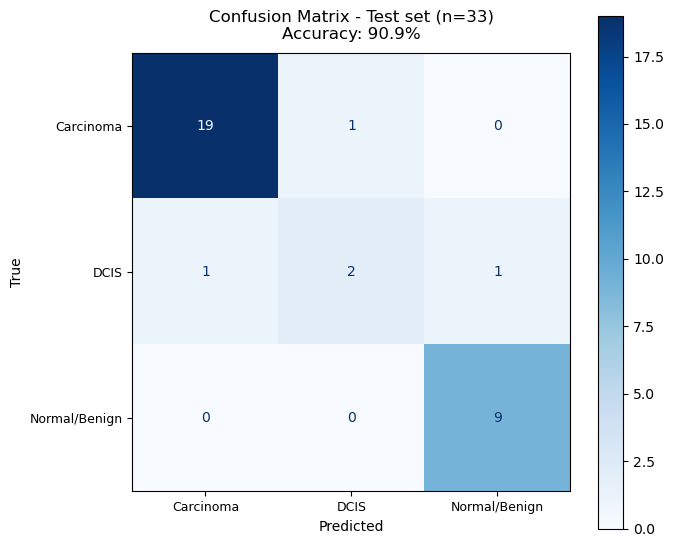

Saved: confusion_matrix.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')

ax.set_title(f'Confusion Matrix - Test set (n={len(y_test)})\nAccuracy: {test_acc:.1%}',
             fontname='DejaVu Sans', fontsize=12, pad=10)
ax.set_xlabel('Predicted', fontname='DejaVu Sans', fontsize=10)
ax.set_ylabel('True', fontname='DejaVu Sans', fontsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('DejaVu Sans')
    label.set_fontsize(9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

## Cell 12: UMAP of core embeddings

We project all core embeddings (train + test) to 2D with UMAP. Each point is one TMA core. Colors encode true class labels.

With `n_neighbors=15` on ~130 points the UMAP is more sensitive to local structure than in Video 2 where we had 2000 points. The clusters should still be broadly coherent - the key question is whether DCIS and Normal/Benign separate from the two carcinoma classes.

Running UMAP ...


c:\Users\m6sbhatt\AppData\Local\anaconda3\envs\torch-gpu-pathology\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


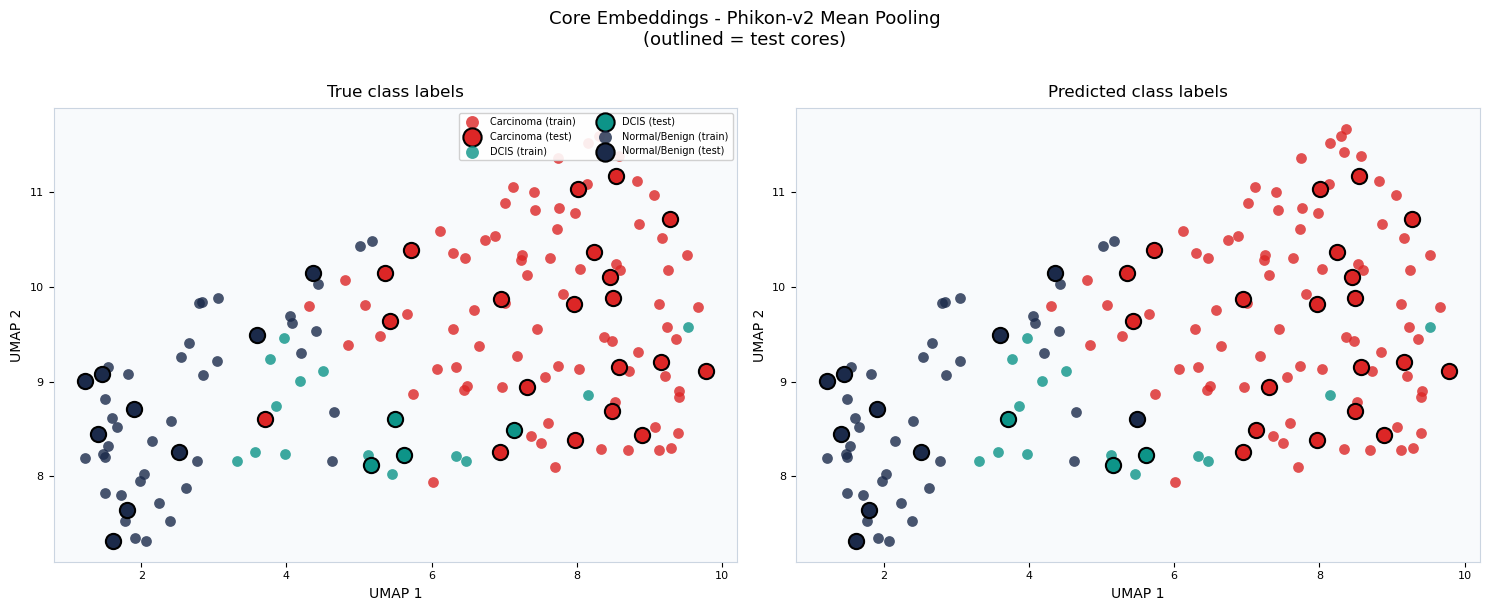

Saved: umap_cores.png


In [13]:
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "umap-learn", "--break-system-packages", "-q"], check=True)
    import umap

# Predict all cores (train + test) for consistent coloring
X_all_sc   = scaler.transform(core_embs)
pred_all   = clf.predict(X_all_sc)
proba_all  = clf.predict_proba(X_all_sc)

print("Running UMAP ...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, n_components=2,
                    metric='cosine', random_state=42)
umap_coords = reducer.fit_transform(core_embs)  # (N_cores, 2)

# Build boolean mask for test cores
test_mask = np.zeros(len(core_embs), dtype=bool)
for pos in pos_test:
    idx = core_positions.index(pos)
    test_mask[idx] = True

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')

for ax_idx, (ax, title, labels) in enumerate([
    (axes[0], 'True class labels', core_labels),
    (axes[1], 'Predicted class labels', pred_all)
]):
    ax.set_facecolor('#F8FAFC')
    for cls_id, (cls_name, cls_color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        mask = labels == cls_id
        # Train cores: filled markers
        ax.scatter(umap_coords[mask & ~test_mask, 0],
                   umap_coords[mask & ~test_mask, 1],
                   c=cls_color, label=f"{cls_name} (train)",
                   s=60, alpha=0.8, linewidths=0)
        # Test cores: larger markers with black edge
        ax.scatter(umap_coords[mask & test_mask, 0],
                   umap_coords[mask & test_mask, 1],
                   c=cls_color, s=120, edgecolors='black',
                   linewidths=1.5, zorder=5,
                   label=f"{cls_name} (test)")

    ax.set_title(title, fontname='DejaVu Sans', fontsize=12, pad=8)
    ax.set_xlabel('UMAP 1', fontname='DejaVu Sans', fontsize=10)
    ax.set_ylabel('UMAP 2', fontname='DejaVu Sans', fontsize=10)
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CBD5E1')
    if ax_idx == 0:
        ax.legend(fontsize=7, markerscale=1.2, ncol=2,
                  loc='upper right', framealpha=0.9)

plt.suptitle('Core Embeddings - Phikon-v2 Mean Pooling\n(outlined = test cores)',
             fontname='DejaVu Sans', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'umap_cores.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_cores.png")

## Cell 13: Tile-level heatmaps for selected cores

The UMAP shows classification at the core level. Now we go back inside individual cores and visualize what is happening at the tile level.

For one core per class we:
1. Tile the core and extract per-tile embeddings (not mean-pooled this time)
2. Apply the trained classifier to each tile independently
3. Reconstruct a spatial probability map showing the predicted class probability at each tile position

This is not how the model was trained - it was trained on mean-pooled core embeddings. But applying it tile-by-tile reveals the spatial heterogeneity within a core. Tiles that look like the assigned class get high probability; tiles that look like stroma or background get lower probability. This is a preview of the attention mechanism concept we build in Video 4 - instead of computing tile relevance post-hoc from a core-level classifier, ABMIL learns it end-to-end.

In [14]:
# Pick one core per class from the test set for visualization
# Use the first correctly classified core in each class
demo_positions = {}
for cls_id in range(len(CLASS_NAMES)):
    for pos, true_lbl, pred_lbl in zip(pos_test, y_test, y_pred):
        if true_lbl == cls_id and pred_lbl == cls_id:
            demo_positions[cls_id] = pos
            break
    if cls_id not in demo_positions:
        # Fall back to first test core of this class even if misclassified
        for pos, true_lbl in zip(pos_test, y_test):
            if true_lbl == cls_id:
                demo_positions[cls_id] = pos
                break

print("Demo cores (one per class):")
for cls_id, pos in demo_positions.items():
    print(f"  {CLASS_NAMES[cls_id]}: {pos}")

Demo cores (one per class):
  Carcinoma: E14
  DCIS: I6
  Normal/Benign: L5


Generating tile-level heatmaps (this may take a few minutes) ...


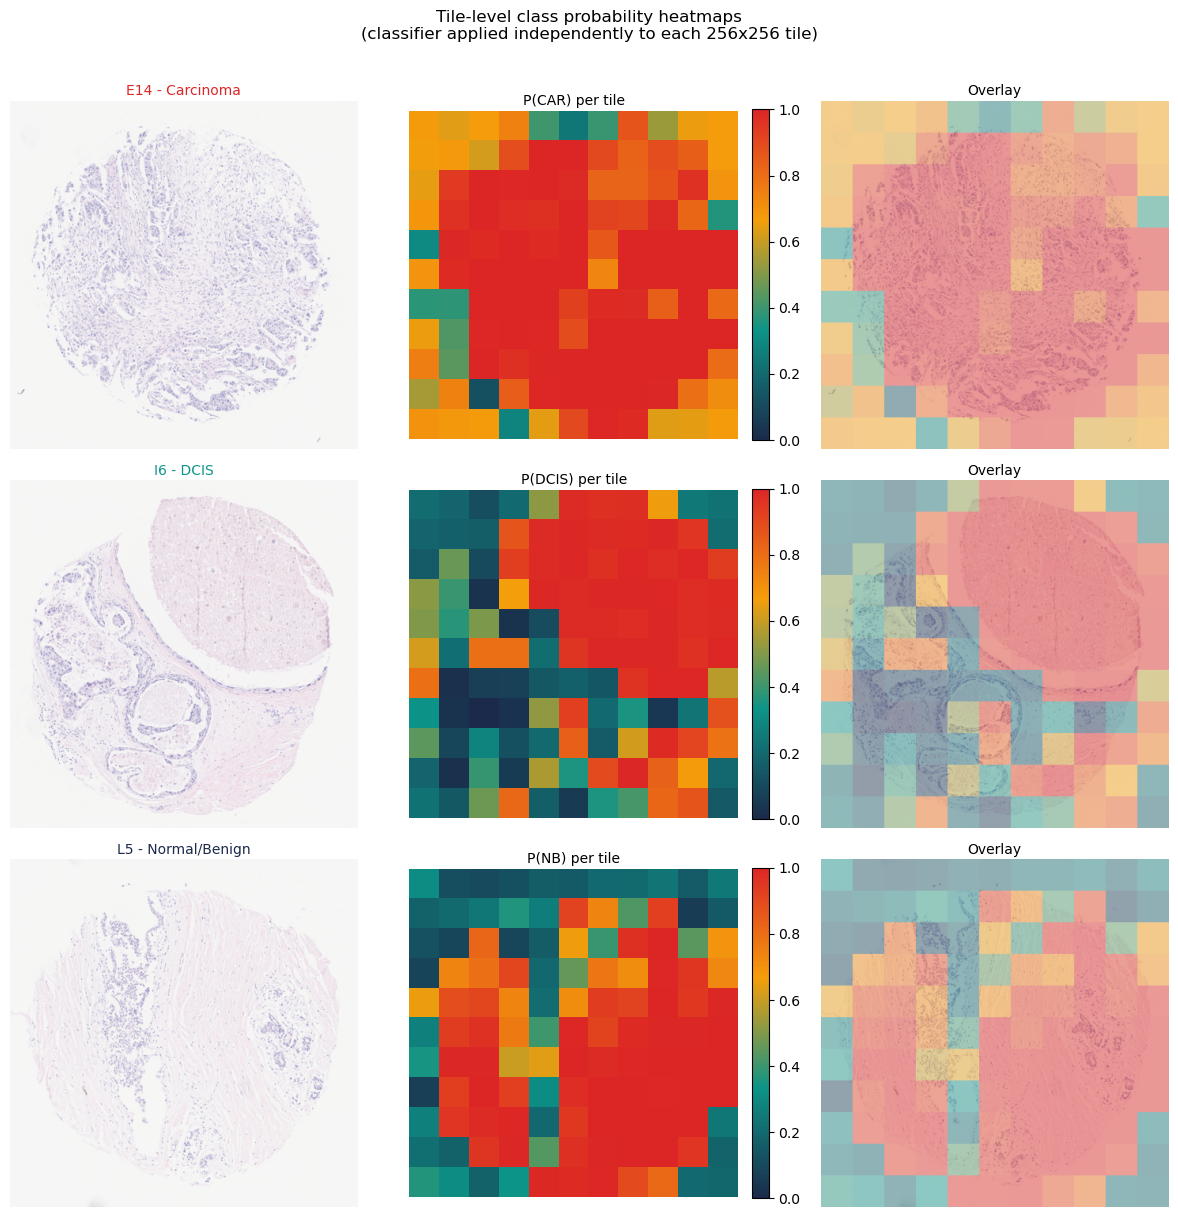

Saved: tile_heatmaps.png


In [15]:
def tile_heatmap(img_path, cls_id_of_interest):
    """
    Tile a core, classify each tile independently, return:
    - img_np: the original image
    - prob_grid: probability of cls_id_of_interest at each tile position
    - n_rows, n_cols: grid dimensions
    """
    img_np = np.array(Image.open(img_path).convert('RGB'))
    H, W   = img_np.shape[:2]
    n_rows = (H - TILE_SIZE) // STRIDE + 1
    n_cols = (W - TILE_SIZE) // STRIDE + 1

    # Tile ALL positions (including background) so we can reconstruct the full grid
    all_tiles, all_rc = [], []
    for r in range(0, H - TILE_SIZE + 1, STRIDE):
        for c in range(0, W - TILE_SIZE + 1, STRIDE):
            all_tiles.append(img_np[r:r + TILE_SIZE, c:c + TILE_SIZE])
            all_rc.append((r, c))

    all_tiles = np.array(all_tiles)

    # Embed all tiles
    tile_embs = embed_tiles(all_tiles)          # (N, 1024)
    tile_embs_sc = scaler.transform(tile_embs)  # use same scaler
    tile_proba = clf.predict_proba(tile_embs_sc) # (N, 4)

    # Build probability grid for the class of interest
    prob_grid = np.zeros((n_rows, n_cols))
    for idx, (r, c) in enumerate(all_rc):
        ri = r // STRIDE
        ci = c // STRIDE
        if ri < n_rows and ci < n_cols:
            prob_grid[ri, ci] = tile_proba[idx, cls_id_of_interest]

    return img_np, prob_grid, n_rows, n_cols


print("Generating tile-level heatmaps (this may take a few minutes) ...")

n_demo = len(demo_positions)
fig, axes = plt.subplots(n_demo, 3, figsize=(12, n_demo * 4))
fig.patch.set_facecolor('white')

cmap_heat = LinearSegmentedColormap.from_list(
    'heat', ['#1B2A4A', '#0D9488', '#F59E0B', '#DC2626'], N=256)

for row_idx, (cls_id, pos) in enumerate(demo_positions.items()):
    img_path = df[df['Position'] == pos].iloc[0]['ImagePath']
    img_np, prob_grid, n_rows, n_cols = tile_heatmap(img_path, cls_id)

    # Downsample original for display
    display_size = n_rows * 40   # scale display to grid dimensions
    img_display = np.array(
        Image.fromarray(img_np).resize((display_size, display_size)))

    cls_color = CLASS_COLORS[cls_id]

    # Panel 1: Original core
    axes[row_idx, 0].imshow(img_display)
    axes[row_idx, 0].axis('off')
    axes[row_idx, 0].set_title(f'{pos} - {CLASS_NAMES[cls_id]}',
                                fontsize=10, fontname='DejaVu Sans',
                                color=cls_color, pad=4)
    if row_idx == 0:
        axes[row_idx, 0].set_ylabel('Original', fontsize=9,
                                     fontname='DejaVu Sans', labelpad=4)

    # Panel 2: Probability heatmap
    im = axes[row_idx, 1].imshow(
        prob_grid, cmap=cmap_heat, vmin=0.0, vmax=1.0,
        aspect='equal')
    axes[row_idx, 1].axis('off')
    axes[row_idx, 1].set_title(f'P({CLASS_SHORT[cls_id]}) per tile',
                                fontsize=10, fontname='DejaVu Sans', pad=4)
    plt.colorbar(im, ax=axes[row_idx, 1], fraction=0.046, pad=0.04)

    # Panel 3: Overlay - heatmap blended onto downsampled core
    # Resize prob grid to display_size
    prob_img = np.array(
        Image.fromarray((prob_grid * 255).astype(np.uint8)).resize(
            (display_size, display_size), resample=Image.NEAREST))
    heatmap_rgb = (cmap_heat(prob_img / 255.0)[:, :, :3] * 255).astype(np.uint8)
    overlay = (img_display.astype(float) * 0.55 +
               heatmap_rgb.astype(float) * 0.45).astype(np.uint8)
    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].axis('off')
    axes[row_idx, 2].set_title('Overlay', fontsize=10,
                                fontname='DejaVu Sans', pad=4)

plt.suptitle('Tile-level class probability heatmaps\n(classifier applied independently to each 256x256 tile)',
             fontname='DejaVu Sans', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tile_heatmaps.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: tile_heatmaps.png")

## Cell 14: What mean pooling loses - preview of ABMIL

The tile heatmaps reveal something important: the class probability is not uniform across the core. Some tiles are confidently classified, others are ambiguous. The mean pooling operation we used to build the core embedding treats all tiles equally - it gives the same weight to a highly informative tumor tile and to a stroma tile with low discriminative value.

This cell quantifies that: for each demo core, we show the distribution of per-tile class probabilities. A wide distribution means the core is heterogeneous - some tiles are clear, others are not. Mean pooling collapses this distribution to a single number and loses the spatial information.

In Video 4 we replace mean pooling with an attention mechanism. The model learns a weight for each tile based on how relevant it is to the classification, and those weights become the attention heatmap.

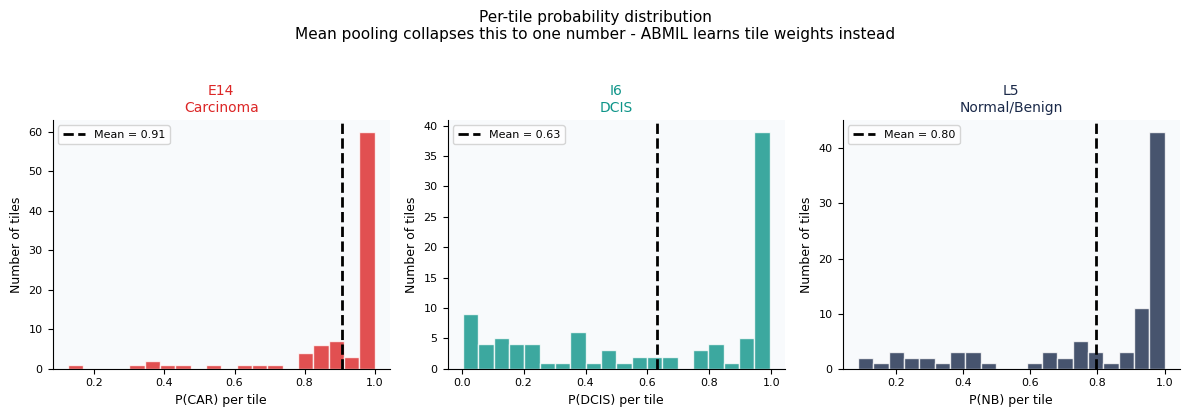

Saved: tile_prob_distributions.png


In [16]:
fig, axes = plt.subplots(1, n_demo, figsize=(4 * n_demo, 4))
fig.patch.set_facecolor('white')

for ax_idx, (cls_id, pos) in enumerate(demo_positions.items()):
    img_path   = df[df['Position'] == pos].iloc[0]['ImagePath']
    img_np     = np.array(Image.open(img_path).convert('RGB'))
    tiles, _   = tile_core(img_np)
    if len(tiles) == 0:
        continue
    tile_embs  = embed_tiles(tiles)
    tile_embs_sc = scaler.transform(tile_embs)
    tile_proba = clf.predict_proba(tile_embs_sc)[:, cls_id]

    ax = axes[ax_idx]
    ax.set_facecolor('#F8FAFC')
    ax.hist(tile_proba, bins=20, color=CLASS_COLORS[cls_id],
            alpha=0.8, edgecolor='white')
    ax.axvline(tile_proba.mean(), color='black', linewidth=2,
               linestyle='--', label=f'Mean = {tile_proba.mean():.2f}')
    ax.set_title(f'{pos}\n{CLASS_NAMES[cls_id]}',
                 fontname='DejaVu Sans', fontsize=10,
                 color=CLASS_COLORS[cls_id])
    ax.set_xlabel(f'P({CLASS_SHORT[cls_id]}) per tile',
                  fontname='DejaVu Sans', fontsize=9)
    ax.set_ylabel('Number of tiles', fontname='DejaVu Sans', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('Per-tile probability distribution\nMean pooling collapses this to one number - ABMIL learns tile weights instead',
             fontname='DejaVu Sans', fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tile_prob_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tile_prob_distributions.png")

## Summary

What we did in this notebook:

1. Loaded 187 TMA core images with pathologist-assigned diagnoses from the BR2082c breast disease spectrum array
2. Tiled each 3000x3000 core into 256x256 patches, filtering background tiles by pixel intensity
3. Extracted Phikon-v2 embeddings for all non-background tiles and mean-pooled them into one 1024-dim vector per core
4. Trained a logistic regression classifier on an 80% stratified train split
5. Evaluated on held-out test cores with a confusion matrix and per-class metrics
6. Visualized core embeddings with UMAP - showing class structure in embedding space
7. Applied the classifier tile-by-tile to selected cores, revealing spatial probability heatmaps
8. Showed that tile probability distributions are heterogeneous within cores - motivating the attention mechanism in Video 4

**In Video 4**, we replace mean pooling with ABMIL - attention-based multiple instance learning. The model learns which tiles to attend to, and the attention weights become an interpretable spatial heatmap showing where on the slide the model is looking.

Code and notebooks: github.com/bnsreenu